In [1]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd
import polars as pl
from pathlib import Path

MARTS_DIR = Path.cwd() / "data" / "marts"

# Витрины v2 (multi-event): дневная динамика, пользователи, контент.
df_daily = pl.read_parquet(MARTS_DIR / "mart_daily_metrics.parquet")
df_users = pl.read_parquet(MARTS_DIR / "mart_user_segments.parquet")
df_items = pl.read_parquet(MARTS_DIR / "mart_content_health.parquet")

# ---- единый стиль графиков ----
# Палитра и спеки — по data-viz гайду: категориальные цвета в фиксированном
# порядке, отдельная ordinal-рампа для тиров, тонкие линии, recessive-сетка.
INK, INK_SECONDARY, INK_MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, BASELINE, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"

BLUE, ORANGE, AQUA, YELLOW = "#2a78d6", "#eb6834", "#1baf7a", "#eda100"
TAIL_C, TORSO_C, HEAD_C = "#86b6ef", "#2a78d6", "#104281"  # ordinal-рампа для тиров

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 11,
    "text.color": INK,
    "axes.edgecolor": BASELINE,
    "axes.labelcolor": INK_SECONDARY,
    "xtick.color": INK_MUTED,
    "ytick.color": INK_MUTED,
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE,
})


def clean_axes(ax, y_grid_only=True):
    """Убирает лишние рамки и делает сетку тонкой и приглушённой."""
    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)
    ax.spines["bottom"].set_color(BASELINE)
    if y_grid_only:
        ax.grid(axis="y", color=GRID, linewidth=1)
        ax.set_axisbelow(True)
        ax.tick_params(axis="y", length=0)
    ax.tick_params(axis="x", length=0)


def k_formatter(x, pos):
    return f"{x/1000:g}K" if x >= 1000 else f"{x:g}"

/tmp/ipykernel_21536/1293860036.py:37: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.91])


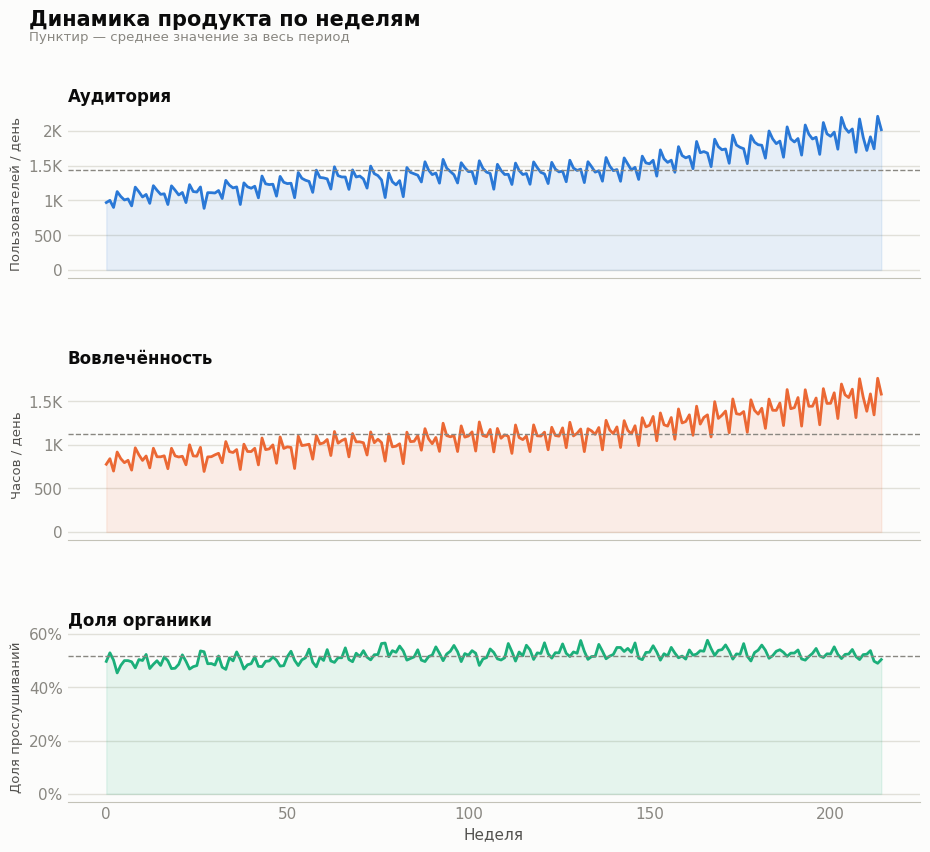

In [2]:
# Динамика продукта по неделям: аудитория, вовлечённость, доля органики.
# Три отдельные шкалы -> три панели друг под другом, а не двойная ось.
pd_daily = df_daily.select(
    ["time_period", "dau", "played_hours", "organic_listen_ratio"]
).to_pandas()
pd_daily["week"] = pd_daily["time_period"] // 7
pd_weekly = (
    pd_daily.groupby("week")[["dau", "played_hours", "organic_listen_ratio"]]
    .mean()
    .reset_index()
)

fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True,
                          gridspec_kw={"hspace": 0.55})

series = [
    ("dau", "Аудитория", "Пользователей / день", BLUE, k_formatter),
    ("played_hours", "Вовлечённость", "Часов / день", ORANGE, k_formatter),
    ("organic_listen_ratio", "Доля органики", "Доля прослушиваний", AQUA,
     lambda x, pos: f"{x:.0%}"),
]

for ax, (col, title, ylabel, color, fmt) in zip(axes, series):
    ax.plot(pd_weekly["week"], pd_weekly[col], color=color, linewidth=2)
    ax.fill_between(pd_weekly["week"], pd_weekly[col], color=color, alpha=0.10)
    ax.axhline(pd_weekly[col].mean(), color=INK_MUTED, linestyle="--", linewidth=1)
    ax.annotate(title, xy=(0, 1.02), xycoords="axes fraction",
                fontsize=12, fontweight="bold", color=INK, ha="left", va="bottom")
    ax.set_ylabel(ylabel, fontsize=9.5)
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(fmt))
    clean_axes(ax)

axes[-1].set_xlabel("Неделя")
fig.suptitle("Динамика продукта по неделям", x=0.09, y=0.99, ha="left",
             fontsize=15, fontweight="bold", color=INK)
fig.text(0.09, 0.955, "Пунктир — среднее значение за весь период", fontsize=9.5, color=INK_MUTED)
plt.tight_layout(rect=[0, 0, 1, 0.91])
plt.show()

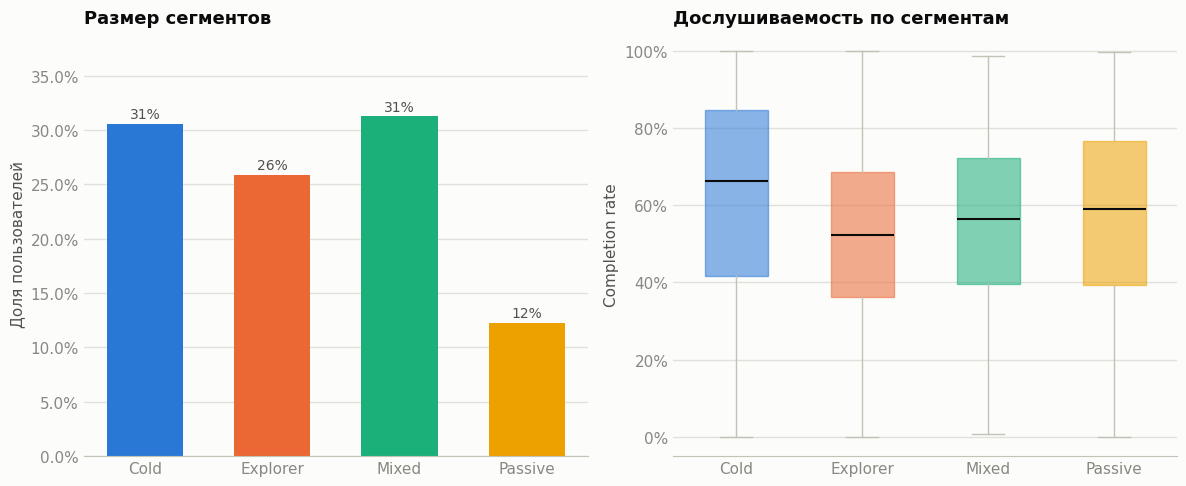

In [3]:
# Сегменты пользователей: размер аудитории и качество прослушивания (completion rate).
pd_users = df_users.to_pandas()
seg_order = ["Cold", "Explorer", "Mixed", "Passive"]
seg_colors = {"Cold": BLUE, "Explorer": ORANGE, "Mixed": AQUA, "Passive": YELLOW}

seg_size = (
    pd_users["segment"].value_counts(normalize=True).reindex(seg_order).reset_index()
)
seg_size.columns = ["segment", "share"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 1. Размер сегментов — один категориальный признак, фиксированный порядок и цвета.
bars = axes[0].bar(seg_size["segment"], seg_size["share"],
                    color=[seg_colors[s] for s in seg_size["segment"]], width=0.6)
for rect, share in zip(bars, seg_size["share"]):
    axes[0].annotate(f"{share:.0%}", (rect.get_x() + rect.get_width() / 2, rect.get_height()),
                      xytext=(0, 4), textcoords="offset points", ha="center",
                      fontsize=10, color=INK_SECONDARY)
axes[0].set_title("Размер сегментов", loc="left", fontsize=13, fontweight="bold", color=INK)
axes[0].set_ylabel("Доля пользователей")
axes[0].yaxis.set_major_formatter(ticker.PercentFormatter(1.0))
axes[0].set_ylim(0, seg_size["share"].max() * 1.25)
clean_axes(axes[0])

# 2. Дослушиваемость по сегментам.
box_data = [pd_users.loc[pd_users["segment"] == s, "completion_rate"].dropna() for s in seg_order]
bp = axes[1].boxplot(
    box_data, tick_labels=seg_order, patch_artist=True, widths=0.5,
    medianprops={"color": INK, "linewidth": 1.5},
    whiskerprops={"color": BASELINE, "linewidth": 1},
    capprops={"color": BASELINE, "linewidth": 1},
    flierprops={"marker": "o", "markersize": 2.5, "markerfacecolor": INK_MUTED,
                "markeredgecolor": "none", "alpha": 0.35},
)
for patch, s in zip(bp["boxes"], seg_order):
    patch.set_facecolor(seg_colors[s])
    patch.set_alpha(0.55)
    patch.set_edgecolor(seg_colors[s])
axes[1].set_title("Дослушиваемость по сегментам", loc="left", fontsize=13, fontweight="bold", color=INK)
axes[1].set_ylabel("Completion rate")
axes[1].yaxis.set_major_formatter(ticker.PercentFormatter(1.0))
clean_axes(axes[1])

plt.tight_layout()
plt.show()

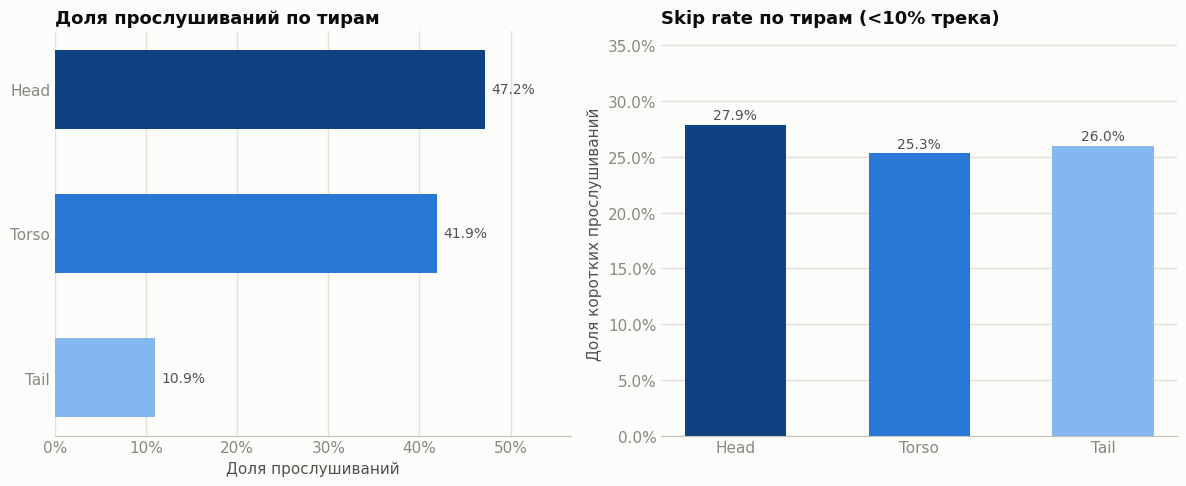

In [4]:
# Здоровье каталога: доля прослушиваний и skip rate по тирам (Head/Torso/Tail).
# Тиры — ordered-категория, поэтому цвет берём из одной ordinal-рампы (не из
# произвольной категориальной палитры), Head = самый тёмный шаг.
pd_items = df_items.to_pandas()
tier_order = ["Head", "Torso", "Tail"]
tier_colors = {"Head": HEAD_C, "Torso": TORSO_C, "Tail": TAIL_C}
pd_items["content_tier"] = pd.Categorical(pd_items["content_tier"], categories=tier_order, ordered=True)

# Skip rate считаем взвешенно по прослушиваниям (sum/sum), а не как среднее
# per-item долей — иначе нишевый трек с парой прослушиваний и хит с 40K
# прослушиваний весили бы одинаково.
tier_stats = pd_items.groupby("content_tier", observed=True).agg(
    listens=("listens", "sum"),
    short_listens=("short_listens", "sum"),
).reset_index()
tier_stats["listen_share"] = tier_stats["listens"] / tier_stats["listens"].sum()
tier_stats["skip_rate"] = tier_stats["short_listens"] / tier_stats["listens"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 1. Доля прослушиваний по тирам — горизонтальный бар, Head сверху.
top_down = tier_stats.set_index("content_tier").loc[tier_order[::-1]].reset_index()
y_pos = range(len(top_down))
bars = axes[0].barh(y_pos, top_down["listen_share"],
                     color=[tier_colors[t] for t in top_down["content_tier"]], height=0.55)
axes[0].set_yticks(list(y_pos))
axes[0].set_yticklabels(top_down["content_tier"])
for rect, share in zip(bars, top_down["listen_share"]):
    axes[0].annotate(f"{share:.1%}", (rect.get_width(), rect.get_y() + rect.get_height() / 2),
                      xytext=(5, 0), textcoords="offset points", va="center",
                      fontsize=10, color=INK_SECONDARY)
axes[0].set_title("Доля прослушиваний по тирам", loc="left", fontsize=13, fontweight="bold", color=INK)
axes[0].set_xlabel("Доля прослушиваний")
axes[0].xaxis.set_major_formatter(ticker.PercentFormatter(1.0))
axes[0].set_xlim(0, top_down["listen_share"].max() * 1.2)
for spine in ["top", "right", "left"]:
    axes[0].spines[spine].set_visible(False)
axes[0].spines["bottom"].set_color(BASELINE)
axes[0].grid(axis="x", color=GRID, linewidth=1)
axes[0].set_axisbelow(True)
axes[0].tick_params(length=0)

# 2. Skip rate по тирам (доля прослушиваний < 10% трека).
bars2 = axes[1].bar(tier_stats["content_tier"], tier_stats["skip_rate"],
                     color=[tier_colors[t] for t in tier_stats["content_tier"]], width=0.55)
for rect, rate in zip(bars2, tier_stats["skip_rate"]):
    axes[1].annotate(f"{rate:.1%}", (rect.get_x() + rect.get_width() / 2, rect.get_height()),
                      xytext=(0, 4), textcoords="offset points", ha="center",
                      fontsize=10, color=INK_SECONDARY)
axes[1].set_title("Skip rate по тирам (<10% трека)", loc="left", fontsize=13, fontweight="bold", color=INK)
axes[1].set_ylabel("Доля коротких прослушиваний")
axes[1].yaxis.set_major_formatter(ticker.PercentFormatter(1.0))
axes[1].set_ylim(0, tier_stats["skip_rate"].max() * 1.3)
clean_axes(axes[1])

plt.tight_layout()
plt.show()